# Decision Tree
A Decision tree is a tree-like structure that represents a set of decisions and their possible consequences. Each node in the tree represents a decision, and each branch represents an outcome of that decision. The leaves of the tree represent the final decisions or predictions.

Decision trees are created by recursively partitioning the data into smaller and smaller subsets. At each partition, the data is split based on a specific feature, and the split is made in a way that maximizes the information gain.

# Key Components of Decision Trees in Python
Root Node: The decision tree’s starting node, which stands for the complete dataset.

Branch Nodes: Internal nodes that represent decision points, where the data is split based on a specific attribute.

Leaf Nodes: Final categorization or prediction-representing terminal nodes.

Decision Rules: Rules that govern the splitting of data at each branch node.

Attribute Selection: The process of choosing the most informative attribute for each split.

Splitting Criteria: Metrics like information gain, entropy, or the Gini Index are used to calculate the optimal split.Key Components of Decision Trees in Python

# Pseudocode of Decision tree
Find the best attribute and place it on the root node of the tree.

Now, split the training set of the dataset into subsets. While making the subset make sure that each subset of training dataset should have the same value for an attribute.

Find leaf nodes in all branches by repeating 1 and 2 on each subset.

# Key concept in Decision Tree
Gini Index: is a metric to measure how often a randomly chosen element would be incorrectly identified. It means an attribute with lower gini index should be preferred.

Entropy: is the measure of uncertainty of a random variable, it characterizes the impurity of an arbitrary collection of examples. The higher the entropy the more the information content.

# Python Decision Tree Implementation

In [30]:
# Importing the required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree



In [12]:
# Load Iris dataset
iris = datasets.load_iris()

# Convert to DataFrame for better readability
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target  # Adding target labels

# Display first 5 rows
print(df.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [13]:
# Split Data into Training and Testing Sets
X = df.drop(columns=['target'])  # Features
y = df['target']  # Labels

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [22]:
# Creating the Decision Tree model
clf = DecisionTreeClassifier(criterion='gini',max_depth=3,random_state=42) # Uses the Gini impurity to decide splits
clf.fit(X_train,y_train)    # max_depth=3 → Limits the tree depth to prevent overfitting.

# predictions
y_pred = clf.predict(X_test)

# Display predictions vs actual values
print("Predictions:", y_pred[:5])
print("\nActual Values:\n", y_test[:5])

# model evaluation
accuracy = accuracy_score(y_test,y_pred)
print(f"\nAccuracy: {accuracy:.2f}")

# confusion matrix
con_matrix = confusion_matrix(y_test,y_pred)
print(f"\nConfusion Matrix:\n", con_matrix)

Predictions: [1 0 2 1 1]

Actual Values:
 73     1
18     0
118    2
78     1
76     1
Name: target, dtype: int32

Accuracy: 1.00

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


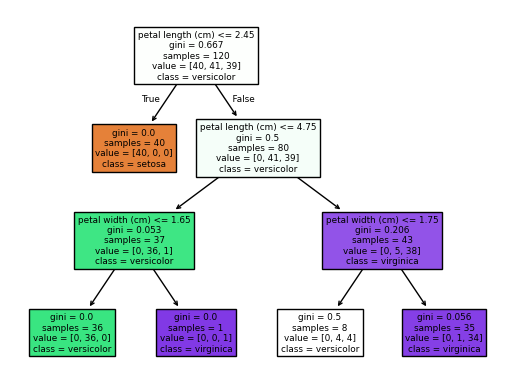

In [28]:
# plot Decisin Tree
plt.Figure(figsize=(12,6))
plot_tree(clf,feature_names=iris.feature_names, class_names=iris.target_names,filled=True)
plt.show()

# Implement a Decision Tree Classifier using a real-life dataset: 
The Titanic dataset. This dataset contains information about passengers on the Titanic and whether they survived or not.

## The Titanic dataset is available in Seaborn as the ‘titanic’ dataset. It consists of the following columns:

Survived: Survival status (0 = No, 1 = Yes)

Pclass: Passenger class (1 = 1st class, 2 = 2nd class, 3 = 3rd class)

Sex: Passenger’s gender

Age: Passenger’s age

SibSp: Number of siblings/spouses aboard

Parch: Number of parents/children aboard

Fare: Fare paid for the ticket

Embarked: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)

Class: Equivalent to Pclass (1 = 1st class, 2 = 2nd class, 3 = 3rd class)

Who: Passenger’s category (man, woman, child)

Adult_male: Whether the passenger is an adult male or not (True or False)

Deck: Cabin deck

Embark_town: Port of embarkation (Cherbourg, Queenstown, Southampton)

Alive: Survival status (yes or no)

Alone: Whether the passenger is alone or not (True or False)

Adult_male: Whether the passenger is an adult male or not (True or False)

Alone: Whether the passenger is alone or not (True or False)

Alive: Survival status (yes or no)

Embarked: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)

Class: Equivalent to Pclass (1 = 1st class, 2 = 2nd class, 3 = 3rd class)

In [105]:
# Load dataset from seaborn
df = sns.load_dataset("titanic")


In [106]:
# Exploring the Data

# Display the first few rows of the dataset
print(df.head())

# Check the dimensions of the dataset
print("\nShape",df.shape)

# Check the data types of variables
print("\nType:\n",df.dtypes)

# Check for missing values
print("\nNull:",df.isnull().sum())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Shape (891, 15)

Type:
 survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
cl

In [107]:
# Data Cleaning:
# Select relevant features
df = df[['survived', 'pclass', 'sex', 'age', 'fare', 'embark_town']]

# Drop rows with missing values
df.dropna(inplace=True)

# Convert categorical variables to numeric
df['sex'] = df["sex"].map({'male':0, 'female':1})
df['embark_town'] = df['embark_town'].map({'Southampton': 0, 'Cherbourg': 1, 'Queenstown': 2})

# Define features and target
X = df.drop(columns=['survived'])
y = df['survived']

In [108]:
# Split the Dataset, training (80%) and testing (20%).

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(f"Training samples: {X_train.shape}")
print(f"Testing samples: {X_test.shape}")


Training samples: (569, 5)
Testing samples: (143, 5)


In [109]:
# Hyperparameter Tuning with Grid Search
from sklearn.model_selection import GridSearchCV

# Define the parameter grid 
params = {
    'max_depth': [3,4,5,6,None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4],
    'criterion': ['gini', 'entropy']
}

# perform grid search
clf = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(clf, params, cv=5,scoring='accuracy',n_jobs=-1)
grid_search.fit(X_train,y_train)

# best parameters
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 4, 'min_samples_split': 10}


In [110]:
# Train the Decision Tree Model
clf = DecisionTreeClassifier(criterion='gini', max_depth=6, min_samples_leaf=4 ,min_samples_split=10, random_state=42)

# Train the model
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=4, min_samples_split=10,
                       random_state=42)

In [111]:
# Make Predictions
# predict on test data
y_pred = clf.predict(X_test)

# Display predictions vs actual values
print("Predictions:", y_pred[:10])
print("Actual:", y_test[:10])

Predictions: [1 1 0 1 0 1 1 1 0 0]
Actual: 641    1
496    1
262    0
311    1
551    0
550    1
279    1
268    1
110    0
554    1
Name: survived, dtype: int64


In [112]:
# Evaluate the Model
# Accuracy Score
accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy:.2f}")

# confusion matrix
cfm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n", cfm)

# classification report
print("Classification Report:\n", classification_report(y_test,y_pred))

Accuracy: 0.78
Confusion Matrix:
 [[72  8]
 [24 39]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.90      0.82        80
           1       0.83      0.62      0.71        63

    accuracy                           0.78       143
   macro avg       0.79      0.76      0.76       143
weighted avg       0.79      0.78      0.77       143



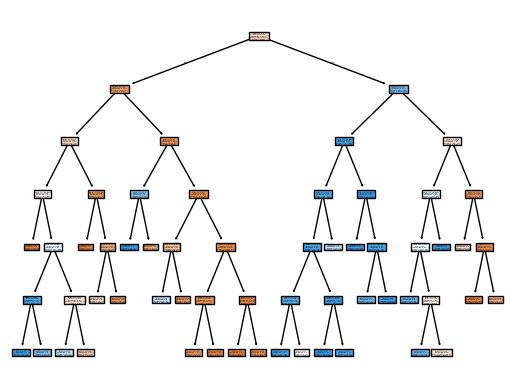

In [116]:
# Visualize the Decision Tree
plt.Figure(figsize=(12,6))
plot_tree(clf,feature_names=X.columns,class_names=['Died','Survived'],filled=True)
plt.show()

# Applications of Decision Trees
Python Decision trees are versatile tools with a wide range of applications in machine learning:

Classification: Making predictions about categorical results, like if an email is spam or not.

Regression: The estimation of continuous values; for example, feature-based home price prediction.

Feature Selection: Feature selection lowers dimensionality and boosts model performance by determining which features are most pertinent to a certain job.

# Conclusion
Python decision trees provide a strong and comprehensible method for handling machine learning tasks. 

They are an invaluable tool for a variety of applications because of their ease of use, efficiency, and capacity to handle both numerical and categorical data. 

Decision trees are a useful tool for making precise forecasts and insightful analysis when used carefully.